## Assignment of Nuclei to Connexin Plaques

- tbd: figure out distances between nuclei (Typical in micrometers)
- figure out how far away connexin can be from the edge

1. Make Delaunay Triangulation between Nuclei Center ( adjust spacing )
2. On the connection points check for closest connexin regions and return a table with connexin regions mapped to 2 nuclei

In [ ]:
# load packages 
from pathlib import Path
BASE_DIR = Path.cwd().parent
import stackview
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util) #good for all my deblurring approaches
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append(str(BASE_DIR / 'src'))
# python files
from cellpose import io
import pandas as pd
from nuclei_assignment import assign_region_to_nuclei


In [8]:
# load the locations of connexin labelled regions and nuclei centers 

# connexin data 
mask_labelled_connexin_regions = io.imread(BASE_DIR / 'data/localization_binary_masks/brightest_region_label_10slides_mask.tiff')
df_region_properties = pd.read_csv(BASE_DIR / 'data/localization_binary_masks/region_properties_10slides.csv')
binary_sauvola_21_stack = io.imread(BASE_DIR / 'data/segmented_images/binary_sauvola3d_21_k0_15_img_10_slides.tiff')
troponin_stack = io.imread(BASE_DIR / 'data/corrected_images/cTnT.tif')

# nuclei data 
df_center_nuclei = pd.read_csv(BASE_DIR / 'data/nuclei_dataset/nuclei_output.csv')
mask_nuclei = io.imread(BASE_DIR / 'data/nuclei_dataset/nuclei_1_raw_Object Identities_test-exported_data_Input.tiff')

100%|██████████| 441/441 [00:02<00:00, 151.25it/s]


In [9]:
# check on the original images if they match 
cnx = io.imread(BASE_DIR / 'data/preprocessed_images/small_deconvolved_3d_planes150_160.tiff') # when loading the original keep in mind the precut section of 15 pixels on top !! 
nuclei = io.imread(BASE_DIR / 'data/corrected_images/nuclei.tif')

100%|██████████| 510/510 [00:09<00:00, 55.32it/s]


### Nuclei don't match my dataset so it needs to be adjusted

In [10]:
# correct the shapes so that i can match the images, nuclei images have new values [69:, :, 26:]
# z muss in Zukunft [60:500] sein 

# -- correct big images ----
# connexin images have new values [:, 15:, :]
# together i would need to precut all raw images like this: [69:, 15:, 26:]
nuclei = nuclei[69:, 15:, 26:1002]
# cnx = cnx[69:, 15:, 26:] # exception because this is already preprocessed
cnx = cnx[:, :, 26:1002]

In [11]:
# -- correct small masks --
# all connexin masks [69:, :, 26:]!! for big image use this 
mask_connexin_regions = mask_labelled_connexin_regions[:, :, 26:1002] # same here 
binary_sauvola_21_stack = binary_sauvola_21_stack[:, :, 26:1002] # same here 
# all nuclei masks [:, 15:, :]
mask_nuclei = mask_nuclei[:, 15:, :]

#correct troponin
troponin_stack = troponin_stack[150:160, :, 26:1002]

C:\Users\laura\AppData\Local\Temp\ipykernel_956\4060645776.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Blues')


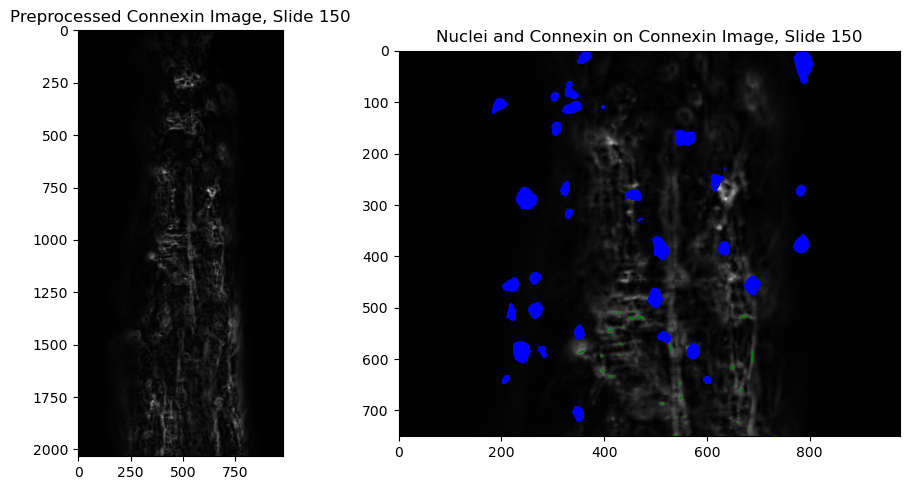

In [18]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# fig.suptitle('Nuclei and Connexin', fontsize=16, y=1.01)

ax[0].imshow(cnx[0], cmap='gray')
ax[0].set_title("Preprocessed Connexin Image, Slide 150")

ax[1].imshow(cnx[0, 500:1250, :], cmap='gray')

# Make background (0) transparent, nuclei visible
cmap = plt.cm.get_cmap('Blues')
colors = cmap(np.arange(cmap.N))
colors[0, -1] = 0  # set alpha=0 only for the 0 value (background)
transparent_cmap = mcolors.ListedColormap(colors)

ax[1].imshow(mask_nuclei[(150+69), 500:1250, :], cmap=mcolors.ListedColormap(['none', 'blue']), interpolation='none')
ax[1].imshow(mask_connexin_regions[0, 500:1250, :], cmap=mcolors.ListedColormap(['none', 'green']), interpolation='none')
ax[1].set_title("Nuclei and Connexin on Connexin Image, Slide 150")

# ax[1].contour(mask_nuclei[(150+69), 500:1250, :], [0.5], linewidths=1.3, colors='b')
# ax[1].contour(mask_connexin_regions[0, 500:1250, :], [0.5], linewidths=0.5, colors='r')

plt.tight_layout()
plt.show()

### Visualize in Napari

In [ ]:
# visualize just the preprocessed connexin in napari
import napari
from napari_animation import Animation

viewer = napari.Viewer()
viewer.add_image(cnx, name='Connexin', opacity=1)
viewer.add_image(mask_nuclei[(150+69):(150+69+10)].astype(bool), name='Nuclei')
viewer.add_image(binary_sauvola_21_stack.astype(int) > 0 , name='Connexin Segmented Areas', colormap='green', opacity = 0.5)

# # Show the orientation axes box (XYZ indicator)
viewer.axes.visible = True
viewer.axes.colored = True   # X=red, Y=green, Z=blue
viewer.axes.dashed = False   # solid lines
viewer.axes.labels = True    # show X, Y, Z labels

# viewer.close()

c:\Users\laura\miniconda3\envs\cardiac_analysis\Lib\site-packages\napari\layers\_layer_actions.py:86: UserWarning: projection mode "none" is not compatible with Labels layers. Falling back to "none".
  warnings.warn(
c:\Users\laura\miniconda3\envs\cardiac_analysis\Lib\site-packages\napari\layers\_layer_actions.py:86: UserWarning: projection mode "none" is not compatible with Labels layers. Falling back to "none".
  warnings.warn(
c:\Users\laura\miniconda3\envs\cardiac_analysis\Lib\site-packages\napari\layers\_layer_actions.py:86: UserWarning: projection mode "none" is not compatible with Labels layers. Falling back to "none".
  warnings.warn(


### Find the nuclei edges

In [19]:
import numpy as np
import pandas as pd
from scipy.spatial import Delaunay
from itertools import combinations


def build_nuclei_edges(nuclei_coords, spacing=(1.0, 0.325, 0.325), max_edge_distance=None):
    """
    Connect neighboring nuclei with a 3D Delaunay triangulation.

    Each edge of the triangulation is treated as a candidate "cell-cell contact"
    between two nuclei. Long edges (nuclei that are actually far apart, but got
    connected because they sit on the outer boundary of the point cloud) are
    removed using a maximum distance cutoff.

    Parameters
    ----------
    nuclei_coords : array, shape (n_nuclei, 3)
        Nuclei centers as [z, y, x], in voxel units.
    spacing : tuple (z, y, x)
        Physical voxel size in micrometers. Needed because triangulating on raw
        voxel coordinates would treat 1 voxel of z as equal to 1 voxel of x/y,
        which is wrong when the voxels are not cubic.
    max_edge_distance : float or None
        Maximum allowed distance (micrometers) between two connected nuclei.
        Edges longer than this are discarded. Use None to keep all edges.

    Returns
    -------
    edges : DataFrame with columns [nucleus_1, nucleus_2, distance_um]
        nucleus_1 / nucleus_2 are row indices into nuclei_coords.
    nuclei_coords_um : array, shape (n_nuclei, 3)
        Same nuclei centers, converted to physical micrometers.
    """
    nuclei_coords = np.asarray(nuclei_coords, dtype=float)
    spacing = np.asarray(spacing, dtype=float)

    # convert voxel indices -> real physical distances (micrometers)
    nuclei_coords_um = nuclei_coords * spacing

    # triangulate in 3D: every nucleus is connected to its natural geometric neighbors
    triangulation = Delaunay(nuclei_coords_um)

    # collect every unique pair of nuclei that share a triangulation cell (simplex)
    unique_pairs = set()
    for simplex in triangulation.simplices:
        for nucleus_a, nucleus_b in combinations(simplex, 2):
            pair = (min(nucleus_a, nucleus_b), max(nucleus_a, nucleus_b))
            unique_pairs.add(pair)

    # compute the real distance for each pair, and drop pairs that are too far apart
    edge_rows = []
    for nucleus_1, nucleus_2 in unique_pairs:
        distance_um = np.linalg.norm(nuclei_coords_um[nucleus_1] - nuclei_coords_um[nucleus_2])
        if max_edge_distance is None or distance_um <= max_edge_distance:
            edge_rows.append({
                'nucleus_1': nucleus_1,
                'nucleus_2': nucleus_2,
                'distance_um': distance_um
            })

    edges = pd.DataFrame(edge_rows)

    print(f"  Nuclei: {len(nuclei_coords)}")
    print(f"  Candidate neighbor pairs found: {len(unique_pairs)}")
    print(f"  Kept after distance filter: {len(edges)}")

    return edges, nuclei_coords_um


In [ ]:
# edges, nuclei_coords_um = build_nuclei_edges(
#     nuclei_coords=df_center_nuclei[['z', 'y', 'x']].values,
#     spacing=(1.0, 0.325, 0.325),
#     max_edge_distance=30.0     # micrometers, tune to your typical inter-nucleus spacing
# )

# matched = match_connexin_to_nuclei_pairs(
#     locations=df_connexin_regions, edges, nuclei_coords_um,
#     spacing=(1.0, 0.325, 0.325),
#     distance_threshold=5.0     # micrometers, tune to expected junction-to-line distance
# )

### Helper Function because I only have 10 slides processed right now (change later)

In [28]:
def align_connexin_z_to_full_stack(locations, z_start_slide):
    """
    Shift connexin region z-coordinates from local crop indices to their
    true position in the full z-stack.

    The connexin regions were detected on a small z-crop of the full stack
    (e.g. only slides 150-160), so their 'z' column currently holds LOCAL
    indices (0, 1, 2, ...) relative to the crop, not the real z-position in
    the full-depth stack that the nuclei were detected in. This adds the
    crop's starting slide number back on, so connexin and nuclei coordinates
    live in the same z reference frame before any distance-based matching.

    Parameters
    ----------
    locations : DataFrame
        Connexin region table (e.g. from get_region_properties_3d), with a
        'z' column in local crop voxel units.
    z_start_slide : int
        Index of the crop's first slide within the full z-stack.
        e.g. if the crop is slides 150-160 of the full stack, z_start_slide = 150.

    Returns
    -------
    locations_aligned : DataFrame
        Copy of `locations` with 'z' replaced by the full-stack z-index.
        All other columns are unchanged.
    """
    locations_aligned = locations.copy()
    locations_aligned['z'] = locations_aligned['z'] + z_start_slide

    print(f"  Shifted connexin z-coordinates by {z_start_slide} slides")
    print(f"  New z range: {locations_aligned['z'].min():.2f} – {locations_aligned['z'].max():.2f}")

    return locations_aligned

### Match Connexin to nuclei pairs

In [21]:
def match_connexin_to_nuclei_pairs(locations, edges, nuclei_coords_um,
                                    spacing=(1.0, 0.325, 0.325),
                                    distance_threshold=None):
    """
    Assign each connexin region to the nuclei pair (candidate cell-cell contact)
    it lies closest to.

    For every connexin region, this checks the distance to every nuclei-pair
    line segment and keeps the closest one. If the region is farther than
    distance_threshold from every segment, it is left unassigned.

    Parameters
    ----------
    locations : DataFrame
        Connexin region table (e.g. from get_region_properties_3d), must
        contain columns ['z', 'y', 'x'] with region centroids in voxel units.
    edges : DataFrame
        Nuclei-pair table from build_nuclei_edges.
    nuclei_coords_um : array, shape (n_nuclei, 3)
        Nuclei centers in physical micrometers, from build_nuclei_edges.
    spacing : tuple (z, y, x)
        Physical voxel size in micrometers, used to convert connexin region
        centroids (voxel units) into the same micrometer units as the nuclei.
    distance_threshold : float or None
        Maximum distance (micrometers) between a connexin region and its
        nearest nuclei-pair line for the match to be accepted. Regions farther
        than this from every line are left unassigned. Use None to always
        assign to the closest line, regardless of distance.

    Returns
    -------
    matched : DataFrame
        Copy of `locations` with four new columns:
        - nucleus_1, nucleus_2 : the matched nuclei pair (NaN if unassigned)
        - nucleus_distance_um  : distance between that pair of nuclei
        - region_to_line_um    : distance from the region to that pair's line
    """
    spacing = np.asarray(spacing, dtype=float)

    # convert connexin region centroids from voxel units -> micrometers
    region_coords_um = locations[['z', 'y', 'x']].to_numpy() * spacing

    # for every edge, get its two endpoints and the vector between them
    nucleus_1_pos = nuclei_coords_um[edges['nucleus_1'].to_numpy()]
    nucleus_2_pos = nuclei_coords_um[edges['nucleus_2'].to_numpy()]
    edge_vectors = nucleus_2_pos - nucleus_1_pos
    edge_lengths_squared = np.sum(edge_vectors ** 2, axis=1)

    matched_nucleus_1 = []
    matched_nucleus_2 = []
    matched_nucleus_distance = []
    matched_region_to_line = []

    for region_point in region_coords_um:

        # project the region onto every edge's line segment, clipped to stay
        # between the two nuclei (not the infinite extension of the line)
        vector_to_region = region_point[None, :] - nucleus_1_pos
        projection_fraction = np.sum(vector_to_region * edge_vectors, axis=1) / edge_lengths_squared
        projection_fraction = np.clip(projection_fraction, 0, 1)

        closest_point_on_edge = nucleus_1_pos + projection_fraction[:, None] * edge_vectors
        distance_to_edge = np.linalg.norm(region_point[None, :] - closest_point_on_edge, axis=1)

        # keep only the single closest edge for this region
        closest_edge_index = np.argmin(distance_to_edge)
        closest_distance = distance_to_edge[closest_edge_index]

        if distance_threshold is not None and closest_distance > distance_threshold:
            # too far from every nuclei pair -> leave unassigned
            matched_nucleus_1.append(np.nan)
            matched_nucleus_2.append(np.nan)
            matched_nucleus_distance.append(np.nan)
        else:
            matched_nucleus_1.append(edges['nucleus_1'].iloc[closest_edge_index])
            matched_nucleus_2.append(edges['nucleus_2'].iloc[closest_edge_index])
            matched_nucleus_distance.append(edges['distance_um'].iloc[closest_edge_index])

        matched_region_to_line.append(closest_distance)

    matched = locations.copy()
    matched['nucleus_1'] = matched_nucleus_1
    matched['nucleus_2'] = matched_nucleus_2
    matched['nucleus_distance_um'] = matched_nucleus_distance
    matched['region_to_line_um'] = matched_region_to_line

    n_assigned = matched['nucleus_1'].notna().sum()
    print(f"  Connexin regions assigned to a nuclei pair: {n_assigned} / {len(matched)}")

    return matched

In [22]:
df_center_nuclei

,X_coordinate,Y_coordinate,Z_coordinate
0,576.25726,1901.07260,46.86085
1,535.87260,2040.38600,42.498104
2,569.69630,1851.51310,39.83358
3,471.98898,1929.68440,41.2166
4,620.76910,1858.25300,22.927675
...,...,...,...
961,203.59355,1650.85950,385.4938
962,215.65509,2001.47600,388.2945
963,259.12442,910.46967,376.93753
964,295.15378,1131.19030,372.36084


In [24]:
# remove spaces and convert to float -> ValueError: could not convert string to float: '354.6 6727'
for col in ['X_coordinate', 'Y_coordinate', 'Z_coordinate']:
    df_center_nuclei[col] = df_center_nuclei[col].astype(str).str.replace(' ', '').astype(float)

In [29]:
# use this when you have full stack 

# nuclei_coords = df_center_nuclei[['Z_coordinate', 'Y_coordinate', 'X_coordinate']].to_numpy()

# edges, nuclei_coords_um = build_nuclei_edges(
#     nuclei_coords,
#     spacing=(1.0, 0.325, 0.325),
#     max_edge_distance=30.0     # micrometers, tune to your typical inter-nucleus spacing
# )

# # connexin regions: locations table needs columns ['z', 'y', 'x'] (voxel centroids)
# print(df_region_properties.columns.tolist())
# locations = df_region_properties  # rename here only if the column names differ

# matched = match_connexin_to_nuclei_pairs(
#     locations, edges, nuclei_coords_um,
#     spacing=(1.0, 0.325, 0.325),
#     distance_threshold=5.0     # micrometers, tune to expected junction-to-line distance
# )

# matched.head()

In [31]:
# --- nuclei centers: reorder columns to [z, y, x] voxel units ---
nuclei_coords = df_center_nuclei[['Z_coordinate', 'Y_coordinate', 'X_coordinate']].to_numpy()

edges, nuclei_coords_um = build_nuclei_edges(
    nuclei_coords,
    spacing=(1.0, 0.325, 0.325),
    max_edge_distance=30.0     # micrometers, tune to your typical inter-nucleus spacing
)

# --- connexin regions: shift local crop z-index (0-9) to full-stack z-index ---
locations_aligned = align_connexin_z_to_full_stack(df_region_properties, z_start_slide=150+69)

matched = match_connexin_to_nuclei_pairs(
    locations_aligned, edges, nuclei_coords_um,
    spacing=(1.0, 0.325, 0.325),
    distance_threshold=5.0     # micrometers, tune to expected junction-to-line distance
)

matched.head()

  Nuclei: 966
  Candidate neighbor pairs found: 7126
  Kept after distance filter: 1799
  Shifted connexin z-coordinates by 219 slides
  New z range: 219.00 – 228.00
  Connexin regions assigned to a nuclei pair: 21 / 372


,label,z,y,x,area_voxels,volume_um3,mean_intensity,nucleus_1,nucleus_2,nucleus_distance_um,region_to_line_um
0,1,223.166667,222.006803,597.892857,588.0,62.107500,6737.299320,NaN,NaN,NaN,15.789127
1,2,223.389520,236.126894,513.419192,1584.0,167.310000,7713.321338,NaN,NaN,NaN,11.425503
2,3,223.866667,244.133333,488.692063,315.0,33.271875,6739.079365,NaN,NaN,NaN,17.005566
3,4,223.736607,243.790179,553.709821,224.0,23.660000,6242.308036,NaN,NaN,NaN,9.153281
4,5,224.023316,247.194301,540.497409,386.0,40.771250,6828.901554,NaN,NaN,NaN,6.941441


### Vizualization of Results

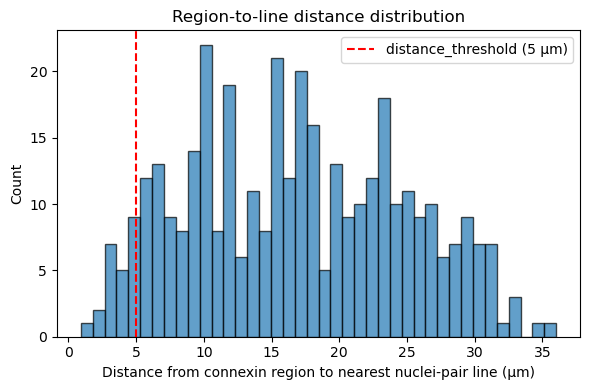

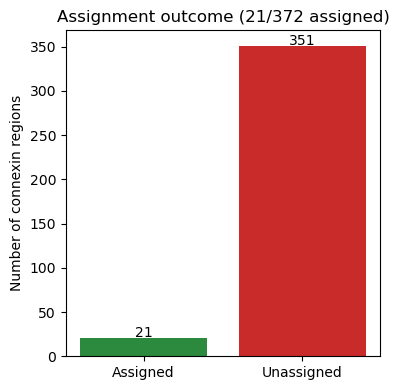

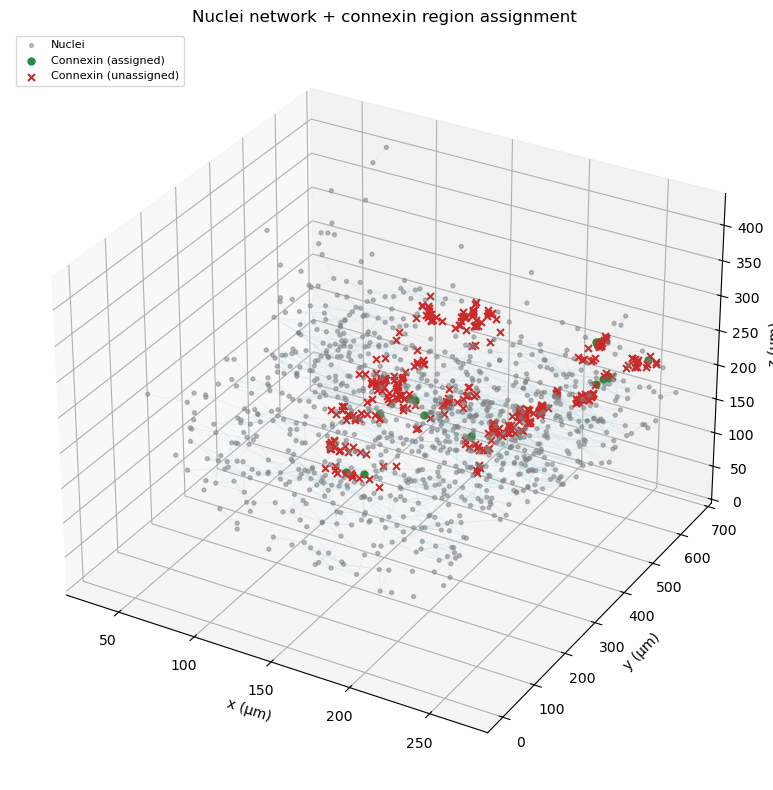

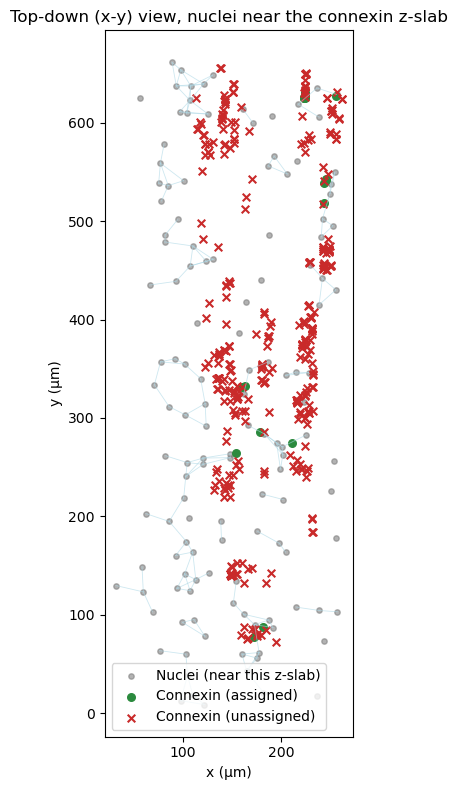

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401, needed for 3d projection

# ============================================================
# 1. Distribution of region-to-line distances (calibration check)
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(matched['region_to_line_um'].dropna(), bins=40, edgecolor='black', alpha=0.7)
ax.axvline(5.0, color='red', linestyle='--', label='distance_threshold (5 µm)')
ax.set_xlabel('Distance from connexin region to nearest nuclei-pair line (µm)')
ax.set_ylabel('Count')
ax.set_title('Region-to-line distance distribution')
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 2. Assigned vs unassigned connexin regions
# ============================================================
n_assigned = matched['nucleus_1'].notna().sum()
n_unassigned = matched['nucleus_1'].isna().sum()

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(['Assigned', 'Unassigned'], [n_assigned, n_unassigned], color=['#2b8a3e', '#c92a2a'])
ax.set_ylabel('Number of connexin regions')
ax.set_title(f'Assignment outcome ({n_assigned}/{len(matched)} assigned)')
for i, v in enumerate([n_assigned, n_unassigned]):
    ax.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.show()

# ============================================================
# 3. 3D scatter: nuclei, Delaunay edges, connexin regions (colored by assignment)
# ============================================================
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection='3d')

# nuclei as small grey dots
ax.scatter(nuclei_coords_um[:, 2], nuclei_coords_um[:, 1], nuclei_coords_um[:, 0],
           s=8, c='grey', alpha=0.5, label='Nuclei')

# Delaunay edges (kept ones) as thin lines
for _, row in edges.iterrows():
    p1 = nuclei_coords_um[int(row['nucleus_1'])]
    p2 = nuclei_coords_um[int(row['nucleus_2'])]
    ax.plot([p1[2], p2[2]], [p1[1], p2[1]], [p1[0], p2[0]],
            color='lightblue', linewidth=0.4, alpha=0.4)

# connexin regions in full-stack coordinates, colored by assignment
locations_aligned_um = locations_aligned[['z', 'y', 'x']].to_numpy() * np.array([1.0, 0.325, 0.325])
assigned_mask = matched['nucleus_1'].notna().to_numpy()

ax.scatter(locations_aligned_um[assigned_mask, 2], locations_aligned_um[assigned_mask, 1],
           locations_aligned_um[assigned_mask, 0],
           s=25, c='#2b8a3e', label='Connexin (assigned)', depthshade=False)
ax.scatter(locations_aligned_um[~assigned_mask, 2], locations_aligned_um[~assigned_mask, 1],
           locations_aligned_um[~assigned_mask, 0],
           s=25, c='#c92a2a', marker='x', label='Connexin (unassigned)', depthshade=False)

ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_zlabel('z (µm)')
ax.set_title('Nuclei network + connexin region assignment')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# ============================================================
# 4. Zoomed 2D top-down view (x-y), since connexin regions only span z=150-159
#    -- easier to read than the full 3D plot for a thin z-slab
# ============================================================
z_lo, z_hi = locations_aligned_um[:, 0].min() - 10, locations_aligned_um[:, 0].max() + 10
nearby_nuclei = (nuclei_coords_um[:, 0] >= z_lo) & (nuclei_coords_um[:, 0] <= z_hi)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(nuclei_coords_um[nearby_nuclei, 2], nuclei_coords_um[nearby_nuclei, 1],
           s=15, c='grey', alpha=0.6, label='Nuclei (near this z-slab)')

for _, row in edges.iterrows():
    n1, n2 = int(row['nucleus_1']), int(row['nucleus_2'])
    if nearby_nuclei[n1] and nearby_nuclei[n2]:
        p1, p2 = nuclei_coords_um[n1], nuclei_coords_um[n2]
        ax.plot([p1[2], p2[2]], [p1[1], p2[1]], color='lightblue', linewidth=0.6, alpha=0.6)

ax.scatter(locations_aligned_um[assigned_mask, 2], locations_aligned_um[assigned_mask, 1],
           s=30, c='#2b8a3e', label='Connexin (assigned)')
ax.scatter(locations_aligned_um[~assigned_mask, 2], locations_aligned_um[~assigned_mask, 1],
           s=30, c='#c92a2a', marker='x', label='Connexin (unassigned)')

ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_title('Top-down (x-y) view, nuclei near the connexin z-slab')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [ ]:
import napari
import numpy as np

viewer = napari.Viewer()

# --- nuclei points, in voxel coordinates (napari applies scale itself) ---
nuclei_coords_voxel = df_center_nuclei[['Z_coordinate', 'Y_coordinate', 'X_coordinate']].to_numpy()
viewer.add_points(
    nuclei_coords_voxel,
    name='nuclei',
    size=8,
    face_color='grey',
    opacity=0.6,
    scale=(1.0, 0.325, 0.325)
)

# --- Delaunay edges as a vectors layer (start point + direction vector per edge) ---
edge_starts = nuclei_coords_voxel[edges['nucleus_1'].to_numpy()]
edge_ends = nuclei_coords_voxel[edges['nucleus_2'].to_numpy()]
edge_vectors_display = np.stack([edge_starts, edge_ends - edge_starts], axis=1)  # (n_edges, 2, 3)

viewer.add_vectors(
    edge_vectors_display,
    name='Delaunay edges',
    edge_color='lightblue',
    edge_width=0.3,
    opacity=0.4,
    scale=(1.0, 0.325, 0.325)
)

# --- connexin regions, shifted to full-stack z, colored by assignment ---
connexin_coords_voxel = locations_aligned[['z', 'y', 'x']].to_numpy()
assigned_mask = matched['nucleus_1'].notna().to_numpy()

viewer.add_points(
    connexin_coords_voxel[assigned_mask],
    name='connexin (assigned)',
    size=6,
    face_color='green',
    scale=(1.0, 0.325, 0.325)
)
viewer.add_points(
    connexin_coords_voxel[~assigned_mask],
    name='connexin (unassigned)',
    size=6,
    face_color='red',
    symbol='x',
    scale=(1.0, 0.325, 0.325)
)

napari.run()

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\laura\miniconda3\envs\cardiac_analysis\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\laura\miniconda3\envs\cardiac_analysis\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\laura\miniconda3\envs\cardiac_analysis\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "c:\Users\laura\miniconda3\envs\cardiac_analysis\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "c:\Users\laura\miniconda3\envs\cardiac_analysis\Lib\asyncio\base_events.py", line 608, in run_forever
    self._run_once()
  File "c:\Users\laura\miniconda3\envs\cardiac_analysis\Lib\asyncio\base_events.py", line 1936, in _run_once
    handle._run()
  File "c:\Users\laura\miniconda

## Use Nfinder to find the cell borders and adjacent cells using the nuclei locations

In [ ]:
# Step 0 — install nfinder
# pip install nfinder

import numpy as np
import pandas as pd
import nfinder
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# ------------------------------------------------------------------ #
# Step 1 — prepare nuclei coordinates for nfinder                     #
# Nfinder expects a (N, 2) or (N, 3) numpy array of coordinates       #
# in whatever unit you want — we convert to µm first   
# Output: a (N, 3) numpy array of nuclei positions in µm in (z, y, x) order. #
# ------------------------------------------------------------------ #
def prepare_nuclei_coords(nuclei_df, xy_pixel_size, z_step_size):
    """
    Convert nuclei DataFrame to physical coordinates for Nfinder.

    Parameters
    ----------
    nuclei_df      : DataFrame with [X_coordinate, Y_coordinate, Z_coordinate] in pixels
    xy_pixel_size  : µm per pixel in xy
    z_step_size    : µm per z step

    Returns
    -------
    nuclei_coords_um : (N, 3) float array in µm, order (z, y, x)
    """
    coords = nuclei_df[[
        'Z_coordinate', 'Y_coordinate', 'X_coordinate'
    ]].values.astype(float)

    coords[:, 0] *= z_step_size    # z → µm
    coords[:, 1] *= xy_pixel_size  # y → µm
    coords[:, 2] *= xy_pixel_size  # x → µm

    print(f"Nuclei: {len(coords)}")
    print(f"  Z range: {coords[:,0].min():.1f} – {coords[:,0].max():.1f} µm")
    print(f"  Y range: {coords[:,1].min():.1f} – {coords[:,1].max():.1f} µm")
    print(f"  X range: {coords[:,2].min():.1f} – {coords[:,2].max():.1f} µm")

    return coords

In [ ]:
# remove spaces and convert to float -> ValueError: could not convert string to float: '354.6 6727'
for col in ['X_coordinate', 'Y_coordinate', 'Z_coordinate']:
    df_center_nuclei[col] = df_center_nuclei[col].astype(str).str.replace(' ', '').astype(float)

In [30]:
coords = prepare_nuclei_coords(df_center_nuclei, xy_pixel_size = 0.325, z_step_size = 1)

Nuclei: 966
  Z range: 22.9 – 415.8 µm
  Y range: 1.3 – 664.2 µm
  X range: 32.1 – 268.5 µm


Edge length statistics (normalized coords):
  Min    : 4.6 µm
  Mean   : 47.6 µm
  Std    : 43.1 µm
  Max    : 629.7 µm
  Auto threshold: 133.9 µm

Expected adjacent nucleus distance: 10–40 µm
Auto threshold looks correct


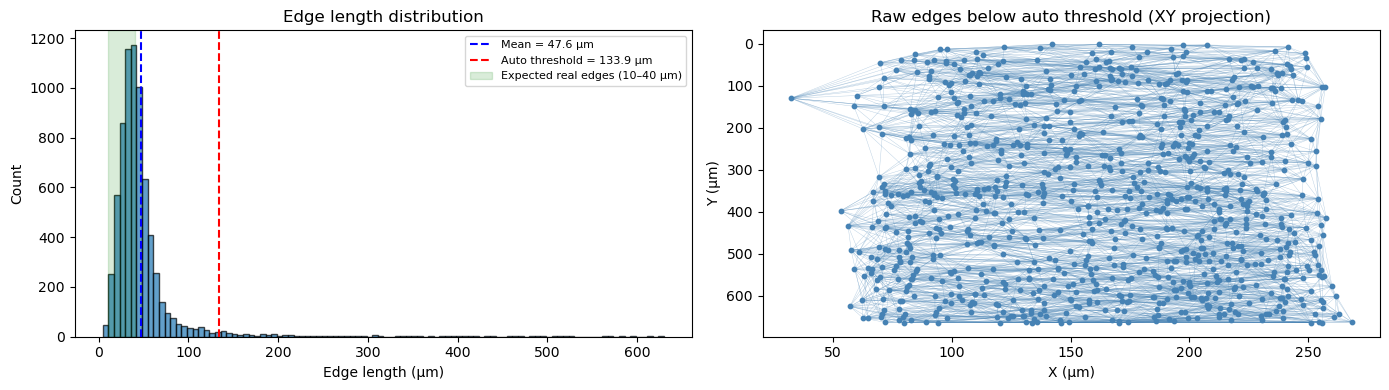

In [34]:
from scipy.spatial import Delaunay
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt

# use normalized coords
tri = Delaunay(nuclei_coords_um)
edges_set = set()
for simplex in tri.simplices:
    for i, j in combinations(simplex, 2):
        edges_set.add((min(i, j), max(i, j)))

all_lengths = np.array([
    np.linalg.norm(nuclei_coords_um[i] - nuclei_coords_um[j])
    for i, j in edges_set
])

auto_threshold = all_lengths.mean() + 2 * all_lengths.std()

print(f"Edge length statistics (normalized coords):")
print(f"  Min    : {all_lengths.min():.1f} µm")
print(f"  Mean   : {all_lengths.mean():.1f} µm")
print(f"  Std    : {all_lengths.std():.1f} µm")
print(f"  Max    : {all_lengths.max():.1f} µm")
print(f"  Auto threshold: {auto_threshold:.1f} µm")

# expected cardiomyocyte nucleus spacing
expected_min = 10   # µm — minimum nucleus-nucleus distance
expected_max = 40   # µm — maximum for adjacent cells

print(f"\nExpected adjacent nucleus distance: {expected_min}–{expected_max} µm")
print(f"Auto threshold {'looks correct' if expected_min < auto_threshold < 200 else 'may need manual adjustment'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# histogram
axes[0].hist(all_lengths, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(all_lengths.mean(), color='blue', linestyle='--',
                label=f'Mean = {all_lengths.mean():.1f} µm')
axes[0].axvline(auto_threshold, color='red', linestyle='--',
                label=f'Auto threshold = {auto_threshold:.1f} µm')
axes[0].axvspan(expected_min, expected_max, alpha=0.15, color='green',
                label=f'Expected real edges ({expected_min}–{expected_max} µm)')
axes[0].set_xlabel('Edge length (µm)')
axes[0].set_ylabel('Count')
axes[0].set_title('Edge length distribution')
axes[0].legend(fontsize=8)

# XY projection of ALL raw edges below threshold
axes[1].set_title('Raw edges below auto threshold (XY projection)')
for i, j in edges_set:
    if all_lengths[list(edges_set).index((i,j))] <= auto_threshold:
        n1 = nuclei_coords_um[i]
        n2 = nuclei_coords_um[j]
        axes[1].plot([n1[2], n2[2]], [n1[1], n2[1]],
                     'steelblue', linewidth=0.3, alpha=0.4)
axes[1].scatter(nuclei_coords_um[:, 2], nuclei_coords_um[:, 1],
                c='steelblue', s=10, zorder=3)
axes[1].set_xlabel('X (µm)')
axes[1].set_ylabel('Y (µm)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

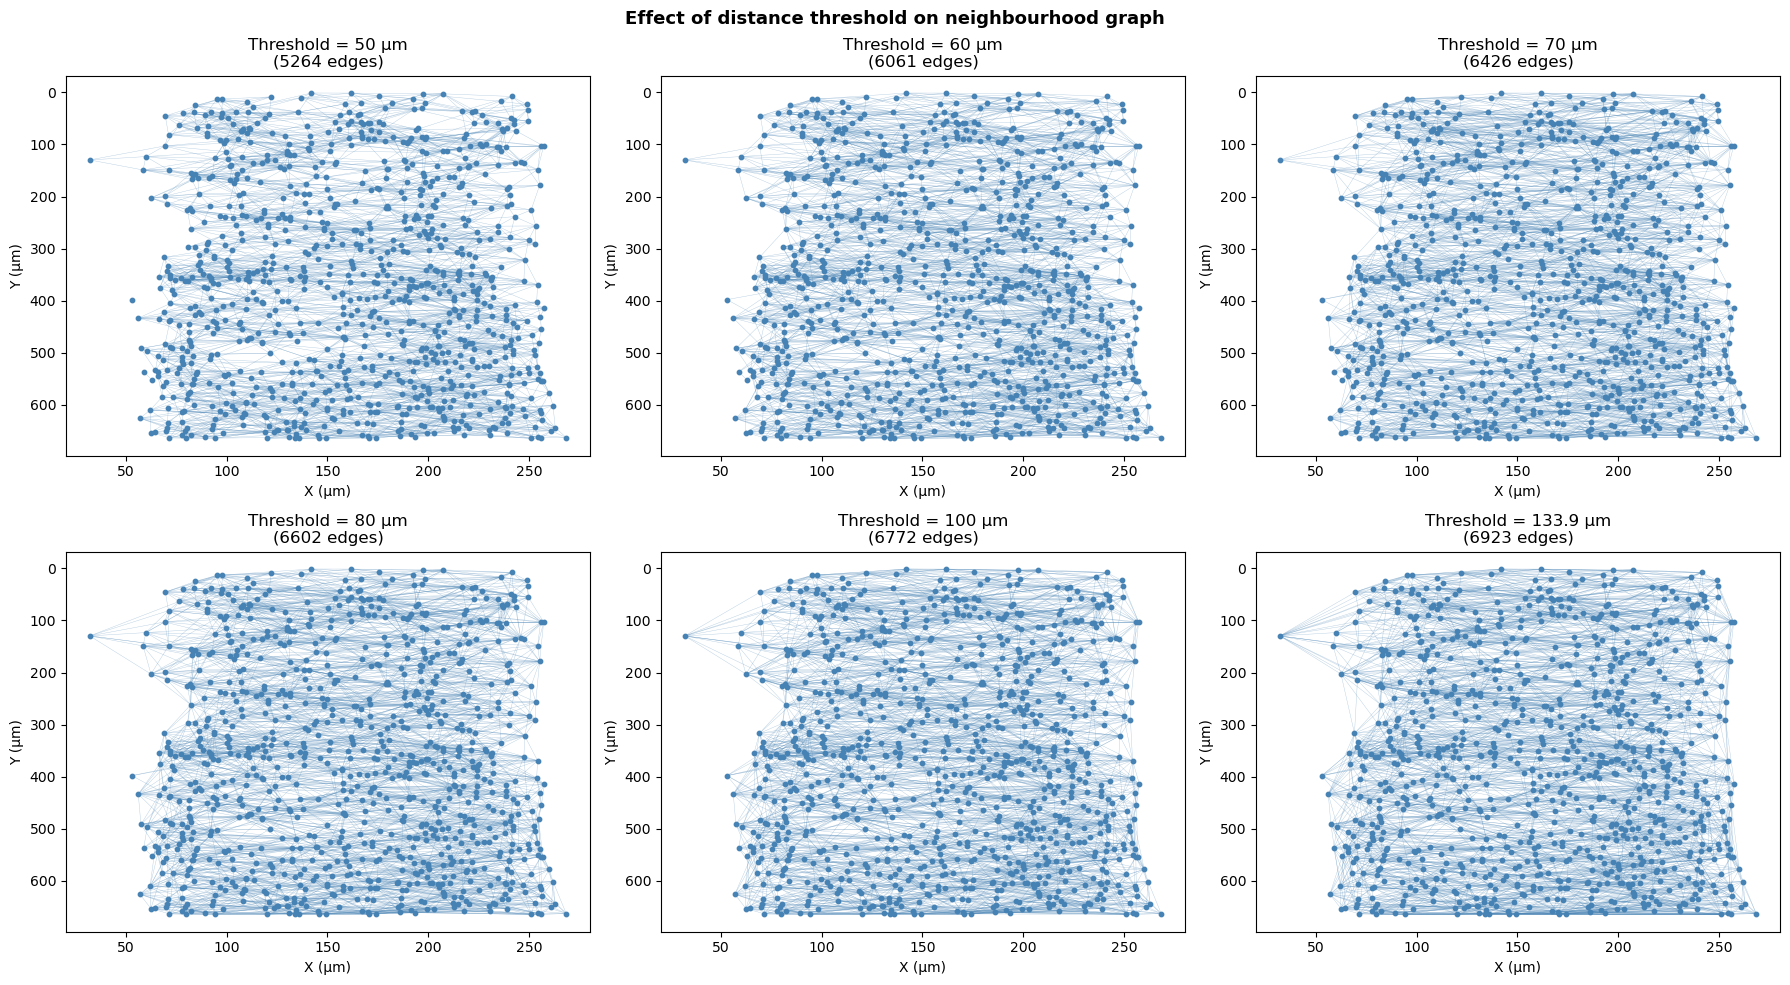

In [35]:
# Auto threshold = 133.9 µm is too permissive
# Looking at your histogram, the distribution drops sharply after ~60-80 µm
# A manual threshold of 60-80 µm would be more appropriate

# First visualize different thresholds to pick the best one
thresholds_to_test = [50, 60, 70, 80, 100, 133.9]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, thresh in zip(axes, thresholds_to_test):
    surviving_edges = [
        (i, j) for (i, j), l in zip(edges_set, all_lengths)
        if l <= thresh
    ]
    for i, j in surviving_edges:
        n1, n2 = nuclei_coords_um[i], nuclei_coords_um[j]
        ax.plot([n1[2], n2[2]], [n1[1], n2[1]],
                'steelblue', linewidth=0.3, alpha=0.4)
    ax.scatter(nuclei_coords_um[:, 2], nuclei_coords_um[:, 1],
               c='steelblue', s=10, zorder=3)
    ax.set_title(f'Threshold = {thresh} µm\n({len(surviving_edges)} edges)')
    ax.set_xlabel('X (µm)')
    ax.set_ylabel('Y (µm)')
    ax.invert_yaxis()

plt.suptitle('Effect of distance threshold on neighbourhood graph',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------ #
# Step 2 — run nfinder to get filtered cell neighbourhood graph       #
# ------------------------------------------------------------------ #
def run_nfinder(nuclei_coords_um):
    """
    Run Nfinder on nuclei coordinates to get filtered Delaunay edges.

    Parameters
    ----------
    nuclei_coords_um : (N, 3) float array in µm (z, y, x)

    Returns
    -------
    edges : list of (i, j) index pairs — one per cell-cell interface
    """
    print("Running Nfinder...")

    # Nfinder's main function — takes coordinate array, returns edge list
    # No free parameters needed — fully automatic filtering
    edges = nfinder.nfinder(nuclei_coords_um)

    print(f"  Cell-cell interfaces found: {len(edges)}")
    return edges

In [ ]:



# ------------------------------------------------------------------ #
# Step 3 — assign connexins to nearest Delaunay edge                  #
# This is NOT in Nfinder — this is your novel contribution            #
# ------------------------------------------------------------------ #
def assign_connexins_to_edges(locations, nuclei_coords_um, edges,
                               xy_pixel_size, z_step_size,
                               max_distance=None):
    """
    Assign each connexin centre to the nearest cell-cell interface
    (Delaunay edge from Nfinder).

    Parameters
    ----------
    locations        : DataFrame with [z, y, x, intensity, area]
    nuclei_coords_um : (N, 3) float array in µm from prepare_nuclei_coords
    edges            : edge list from run_nfinder
    xy_pixel_size    : µm per pixel in xy
    z_step_size      : µm per z step
    max_distance     : max distance in µm for valid assignment, or None

    Returns
    -------
    result : DataFrame — one row per connexin with assignment columns
    """

    # convert connexin pixel coords to µm
    connexin_coords_um = np.column_stack([
        locations['z'].values * z_step_size,
        locations['y'].values * xy_pixel_size,
        locations['x'].values * xy_pixel_size
    ])

    def point_to_segment_distance(p, a, b):
        """Distance from point p to segment a->b, and projection t."""
        ab = b - a
        length_sq = np.dot(ab, ab)
        if length_sq == 0:
            return np.linalg.norm(p - a), 0.0
        t = np.clip(np.dot(p - a, ab) / length_sq, 0, 1)
        return np.linalg.norm(p - (a + t * ab)), t

    print("Assigning connexins to cell-cell interfaces...")
    records = []

    for i, cx in enumerate(connexin_coords_um):
        best_edge = None
        best_dist = np.inf
        best_t    = None

        for idx1, idx2 in edges:
            n1 = nuclei_coords_um[idx1]
            n2 = nuclei_coords_um[idx2]
            dist, t = point_to_segment_distance(cx, n1, n2)
            if dist < best_dist:
                best_dist = dist
                best_edge = (idx1, idx2)
                best_t    = t

        assigned = (max_distance is None) or (best_dist <= max_distance)

        records.append({
            **locations.iloc[i].to_dict(),
            'z_um'          : round(cx[0], 3),
            'y_um'          : round(cx[1], 3),
            'x_um'          : round(cx[2], 3),
            'nucleus_1_idx' : best_edge[0] if best_edge else None,
            'nucleus_2_idx' : best_edge[1] if best_edge else None,
            'edge_dist_um'  : round(best_dist, 3),
            't_value'       : round(best_t, 3) if best_t is not None else None,
            'assigned'      : assigned
        })

    result = pd.DataFrame(records)
    print(f"  Assigned  : {result['assigned'].sum()} connexins")
    print(f"  Unassigned: {(~result['assigned']).sum()} connexins")
    return result


# ------------------------------------------------------------------ #
# Step 4 — visualize                                                  #
# ------------------------------------------------------------------ #
def visualize_assignment(result, nuclei_coords_um, edges,
                          stack_float, xy_pixel_size, z_step_size,
                          z_plane=None, save_path=None):
    """
    4-panel visualization of the full pipeline.
    """
    import matplotlib.patches as mpatches

    if z_plane is None:
        z_plane = int(result['z'].median())

    nuclei_xy = nuclei_coords_um[:, [2, 1]]
    x_min, x_max = nuclei_xy[:, 0].min(), nuclei_xy[:, 0].max()
    y_min, y_max = nuclei_xy[:, 1].min(), nuclei_xy[:, 1].max()

    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('Connexin Assignment via Nfinder Delaunay Graph',
                 fontsize=14, fontweight='bold')

    # Panel 1 — Nfinder graph XY projection
    ax = axes[0, 0]
    for i, j in edges:
        n1, n2 = nuclei_xy[i], nuclei_xy[j]
        ax.plot([n1[0], n2[0]], [n1[1], n2[1]],
                'steelblue', linewidth=0.5, alpha=0.4)
    ax.scatter(nuclei_xy[:, 0], nuclei_xy[:, 1],
               c='steelblue', s=20, zorder=3, label='Nuclei')
    ax.scatter(result['x_um'], result['y_um'],
               c='red', s=10, zorder=4, label='Connexins')
    ax.set_title(f'Nfinder graph (XY)\n{len(edges)} cell-cell interfaces')
    ax.set_xlabel('X (µm)')
    ax.set_ylabel('Y (µm)')
    ax.legend(fontsize=8)
    ax.set_xlim(x_min - 10, x_max + 10)
    ax.set_ylim(y_min - 10, y_max + 10)

    # Panel 2 — connexins coloured by distance to nearest edge
    ax = axes[0, 1]
    for i, j in edges:
        n1, n2 = nuclei_xy[i], nuclei_xy[j]
        ax.plot([n1[0], n2[0]], [n1[1], n2[1]],
                'lightgray', linewidth=0.5, alpha=0.5)
    sc = ax.scatter(result['x_um'], result['y_um'],
                    c=result['edge_dist_um'], cmap='RdYlGn_r',
                    s=20, zorder=4)
    plt.colorbar(sc, ax=ax, label='Distance to edge (µm)')
    ax.scatter(nuclei_xy[:, 0], nuclei_xy[:, 1],
               c='steelblue', s=20, zorder=3)
    ax.set_title('Connexins coloured by\ndistance to nearest interface')
    ax.set_xlabel('X (µm)')
    ax.set_ylabel('Y (µm)')
    ax.set_xlim(x_min - 10, x_max + 10)
    ax.set_ylim(y_min - 10, y_max + 10)

    # Panel 3 — assignment lines
    ax = axes[1, 0]
    for i, j in edges:
        n1, n2 = nuclei_xy[i], nuclei_xy[j]
        ax.plot([n1[0], n2[0]], [n1[1], n2[1]],
                'lightgray', linewidth=0.5, alpha=0.4)
    ax.scatter(nuclei_xy[:, 0], nuclei_xy[:, 1],
               c='steelblue', s=20, zorder=3)
    for _, row in result[result['assigned']].iterrows():
        n1 = nuclei_coords_um[int(row['nucleus_1_idx'])]
        n2 = nuclei_coords_um[int(row['nucleus_2_idx'])]
        color = 'green' if row['edge_dist_um'] <= 10 else 'orange'
        ax.plot([row['x_um'], n1[2]], [row['y_um'], n1[1]],
                color=color, linewidth=0.5, alpha=0.6)
        ax.plot([row['x_um'], n2[2]], [row['y_um'], n2[1]],
                color=color, linewidth=0.5, alpha=0.6)
        ax.plot(row['x_um'], row['y_um'], 'r.', markersize=3, zorder=4)
    green_p  = mpatches.Patch(color='green',  label='≤10 µm from edge')
    orange_p = mpatches.Patch(color='orange', label='>10 µm from edge')
    ax.legend(handles=[green_p, orange_p], fontsize=8)
    ax.set_title('Assignment: connexin → 2 nuclei')
    ax.set_xlabel('X (µm)')
    ax.set_ylabel('Y (µm)')
    ax.set_xlim(x_min - 10, x_max + 10)
    ax.set_ylim(y_min - 10, y_max + 10)

    # Panel 4 — raw image overlay for one z-plane
    ax = axes[1, 1]
    ax.imshow(stack_float[z_plane], cmap='gray', origin='upper')
    nearby_nuclei = nuclei_coords_um[
        np.abs(nuclei_coords_um[:, 0] / z_step_size - z_plane) < 10
    ]
    ax.scatter(nearby_nuclei[:, 2] / xy_pixel_size,
               nearby_nuclei[:, 1] / xy_pixel_size,
               c='cyan', s=40, marker='x', linewidths=1.5,
               label='Nuclei', zorder=3)
    plane_result = result[result['z'] == z_plane]
    for _, row in plane_result[plane_result['assigned']].iterrows():
        n1 = nuclei_coords_um[int(row['nucleus_1_idx'])]
        n2 = nuclei_coords_um[int(row['nucleus_2_idx'])]
        color = 'lime' if row['edge_dist_um'] <= 10 else 'orange'
        ax.plot([row['x'], n1[2] / xy_pixel_size],
                [row['y'], n1[1] / xy_pixel_size],
                color=color, linewidth=0.8)
        ax.plot([row['x'], n2[2] / xy_pixel_size],
                [row['y'], n2[1] / xy_pixel_size],
                color=color, linewidth=0.8)
        ax.plot(row['x'], row['y'], 'r.', markersize=4, zorder=4)
    ax.set_title(f'Raw image overlay — z-plane {z_plane}')
    ax.legend(fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"Saved to {save_path}")
    plt.show()


# ------------------------------------------------------------------ #
# Full pipeline                                                        #
# ------------------------------------------------------------------ #
XY_PIXEL_SIZE = 0.1   # µm per pixel — replace with your value
Z_STEP_SIZE   = 0.5   # µm per z step — replace with your value

# Step 1 — prepare coordinates
nuclei_coords_um = prepare_nuclei_coords(
    df_center_nuclei, XY_PIXEL_SIZE, Z_STEP_SIZE
)

# Step 2 — run nfinder (their code, fully automatic)
edges = run_nfinder(nuclei_coords_um)

# Step 3 — assign connexins to edges (your novel contribution)
result = assign_connexins_to_edges(
    locations,
    nuclei_coords_um,
    edges,
    xy_pixel_size = XY_PIXEL_SIZE,
    z_step_size   = Z_STEP_SIZE,
    max_distance  = 20.0   # µm — tune based on your distance distribution
)

# Step 4 — visualize
visualize_assignment(
    result,
    nuclei_coords_um,
    edges,
    stack_float,
    xy_pixel_size = XY_PIXEL_SIZE,
    z_step_size   = Z_STEP_SIZE,
    z_plane       = 5,
    save_path     = 'nfinder_assignment.png'
)

result.to_csv('connexin_assignments.csv', index=False)

In [ ]:
#Find neighbors graph
edges = nfinder.neighbors_graph(points)

## Map the Nuclei Centers with Connexin Regions

In [11]:
import numpy as np
import pandas as pd
from scipy.spatial import Delaunay, cKDTree
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import combinations

def build_delaunay_graph(nuclei_df, xy_pixel_size, z_step_size,
                          distance_threshold=None, angle_threshold=90.0):
    """
    Build filtered Delaunay triangulation graph of nuclei centroids.
    Implements Nfinder filtering (Blasse et al. 2023):
    1. Distance filter  — remove edges longer than threshold
    2. Angle filter     — remove edges where angle with shared neighbour is too large

    Parameters
    ----------
    nuclei_df          : DataFrame with columns [X_coordinate, Y_coordinate, Z_coordinate]
    xy_pixel_size      : µm per pixel in xy
    z_step_size        : µm per z step
    distance_threshold : maximum allowed edge length in µm.
                         None = auto-threshold using mean + 2*std of all edge lengths
    angle_threshold    : maximum angle in degrees a pair subtends with shared neighbours
                         Nfinder default = 90 degrees

    Returns
    -------
    nuclei_coords_um : (M, 3) array of nuclei coordinates in µm (z, y, x)
    edges            : list of (i, j) index pairs — filtered Delaunay edges
    edge_lengths     : array of edge lengths in µm
    """

    # ------------------------------------------------------------------ #
    # Step 1 — convert nuclei to physical units                           #
    # ------------------------------------------------------------------ #
    nuclei_coords_um = nuclei_df[[
        'Z_coordinate', 'Y_coordinate', 'X_coordinate'
    ]].values.astype(float)

    # nuclei CSV is already in pixels — convert to µm
    nuclei_coords_um[:, 0] *= z_step_size    # z
    nuclei_coords_um[:, 1] *= xy_pixel_size  # y
    nuclei_coords_um[:, 2] *= xy_pixel_size  # x

    # ------------------------------------------------------------------ #
    # Step 2 — build 3D Delaunay triangulation                            #
    # ------------------------------------------------------------------ #
    print("Step 1: Building 3D Delaunay triangulation...")
    tri = Delaunay(nuclei_coords_um) # Delaunay triangulation but here tetrahedron 

    # extract unique edges from tetrahedra
    edges_set = set()
    for simplex in tri.simplices:
        for i, j in combinations(simplex, 2):
            edge = (min(i, j), max(i, j))
            edges_set.add(edge)
    all_edges = list(edges_set)
    print(f"  Raw Delaunay edges: {len(all_edges)}")

    # compute edge lengths (eudclidean distance in µm)
    all_lengths = np.array([
        np.linalg.norm(nuclei_coords_um[i] - nuclei_coords_um[j])
        for i, j in all_edges
    ])

    # ------------------------------------------------------------------ #
    # Step 3 — distance filter                                            #
    # ------------------------------------------------------------------ #
    if distance_threshold is None:
        # auto threshold: mean + 2*std (Nfinder approach)
        distance_threshold = all_lengths.mean() + 2 * all_lengths.std()
        print(f"  Auto distance threshold: {distance_threshold:.1f} µm")
    else:
        print(f"  Distance threshold: {distance_threshold:.1f} µm")

    dist_mask = all_lengths <= distance_threshold
    edges_dist = [e for e, m in zip(all_edges, dist_mask) if m]
    lengths_dist = all_lengths[dist_mask]
    print(f"  After distance filter: {len(edges_dist)} edges")

    # ------------------------------------------------------------------ #
    # Step 4 — angle filter (non-pairwise interaction)                    #
    # For each edge (i,j), find shared neighbours k                       #
    # Compute angle subtended at k by the pair (i,j)                     #
    # Remove edge if max angle across all shared neighbours > threshold   #
    # ------------------------------------------------------------------ #
    print("Step 2: Applying angle filter...")

    # build adjacency list from distance-filtered edges
    adjacency = {i: set() for i in range(len(nuclei_coords_um))}
    for i, j in edges_dist:
        adjacency[i].add(j)
        adjacency[j].add(i)

    def angle_at_k(i, j, k, coords):
        """Angle at vertex k in triangle (i, j, k) in degrees."""
        v1 = coords[i] - coords[k]
        v2 = coords[j] - coords[k]
        cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10)
        cos_angle = np.clip(cos_angle, -1, 1)
        return np.degrees(np.arccos(cos_angle))

    filtered_edges = []
    filtered_lengths = []

    for (i, j), length in zip(edges_dist, lengths_dist):
        # find shared neighbours
        shared = adjacency[i] & adjacency[j]

        if len(shared) == 0:
            # no shared neighbours — keep edge
            filtered_edges.append((i, j))
            filtered_lengths.append(length)
            continue

        # compute max angle at any shared neighbour
        angles = [angle_at_k(i, j, k, nuclei_coords_um) for k in shared]
        max_angle = max(angles)

        if max_angle <= angle_threshold:
            filtered_edges.append((i, j))
            filtered_lengths.append(length)

    filtered_lengths = np.array(filtered_lengths)
    print(f"  After angle filter   : {len(filtered_edges)} edges")
    print(f"  Edge length — mean: {filtered_lengths.mean():.1f} µm, "
          f"std: {filtered_lengths.std():.1f} µm, "
          f"max: {filtered_lengths.max():.1f} µm")

    return nuclei_coords_um, filtered_edges, filtered_lengths


def assign_connexins_to_edges(locations, nuclei_coords_um, edges,
                               xy_pixel_size, z_step_size,
                               max_distance=None):
    """
    Assign each connexin to the nearest Delaunay edge.
    Each edge represents one cell-cell interface between 2 nuclei.

    Parameters
    ----------
    locations        : DataFrame with columns [z, y, x, intensity, area]
    nuclei_coords_um : (M, 3) array of nuclei coordinates in µm from build_delaunay_graph
    edges            : filtered Delaunay edges from build_delaunay_graph
    xy_pixel_size    : µm per pixel in xy
    z_step_size      : µm per z step
    max_distance     : maximum distance in µm from edge for valid assignment

    Returns
    -------
    result : DataFrame with assignment columns added
    """

    # ------------------------------------------------------------------ #
    # Step 1 — convert connexin coordinates to µm                         #
    # ------------------------------------------------------------------ #
    connexin_coords_um = np.column_stack([
        locations['z'].values * z_step_size,
        locations['y'].values * xy_pixel_size,
        locations['x'].values * xy_pixel_size
    ])

    # ------------------------------------------------------------------ #
    # Step 2 — for each connexin find nearest Delaunay edge               #
    # distance from point to line segment (not infinite line)             #
    # ------------------------------------------------------------------ #
    def point_to_segment_distance(p, a, b):
        """
        Distance from point p to line segment a->b.
        Also returns t (projection parameter):
            t=0 → closest point is a
            t=1 → closest point is b
            0<t<1 → closest point is on the segment
        """
        ab = b - a
        length_sq = np.dot(ab, ab)
        if length_sq == 0:
            return np.linalg.norm(p - a), 0.0
        t = np.clip(np.dot(p - a, ab) / length_sq, 0, 1)
        closest = a + t * ab
        return np.linalg.norm(p - closest), t

    print("Assigning connexins to Delaunay edges...")
    records = []

    for i, cx in enumerate(connexin_coords_um):
        best_edge     = None
        best_dist     = np.inf
        best_t        = None

        for idx1, idx2 in edges:
            n1 = nuclei_coords_um[idx1]
            n2 = nuclei_coords_um[idx2]
            dist, t = point_to_segment_distance(cx, n1, n2)

            if dist < best_dist:
                best_dist = dist
                best_edge = (idx1, idx2)
                best_t    = t

        # apply max distance filter
        if max_distance is not None:
            assigned = best_dist <= max_distance
        else:
            assigned = True

        records.append({
            **locations.iloc[i].to_dict(),
            'z_um'          : round(cx[0], 3),
            'y_um'          : round(cx[1], 3),
            'x_um'          : round(cx[2], 3),
            'nucleus_1_idx' : best_edge[0] if best_edge else None,
            'nucleus_2_idx' : best_edge[1] if best_edge else None,
            'edge_dist_um'  : round(best_dist, 3),
            't_value'       : round(best_t, 3) if best_t is not None else None,
            'assigned'      : assigned
        })

    result = pd.DataFrame(records)
    n_assigned   = result['assigned'].sum()
    n_unassigned = (~result['assigned']).sum()
    print(f"  Assigned  : {n_assigned} connexins")
    print(f"  Unassigned: {n_unassigned} connexins (>{max_distance} µm from any edge)")

    return result


def visualize_delaunay_assignment(result, nuclei_coords_um, edges,
                                   stack_float, xy_pixel_size, z_step_size,
                                   z_plane=None, save_path=None):
    """
    Visualize the Delaunay + connexin assignment in 4 panels.

    Parameters
    ----------
    result           : DataFrame from assign_connexins_to_edges
    nuclei_coords_um : (M, 3) array of nuclei in µm
    edges            : filtered Delaunay edges
    stack_float      : 3D float array (z, y, x)
    xy_pixel_size    : µm per pixel
    z_step_size      : µm per z step
    z_plane          : z-plane index for raw image overlay panel
    save_path        : path to save figure or None
    """
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize
    import matplotlib.patches as mpatches

    if z_plane is None:
        z_plane = int(result['z'].median())

    fig = plt.figure(figsize=(22, 16))
    fig.suptitle('Connexin Assignment via Delaunay Triangulation (Nfinder approach)',
                 fontsize=14, fontweight='bold')

    # XY projection coordinates for 2D panels
    nuclei_xy = nuclei_coords_um[:, [2, 1]]  # (X, Y) in µm
    cx_xy     = result[['x_um', 'y_um']].values
    assigned  = result['assigned'].values
    edge_dist = result['edge_dist_um'].values

    x_min, x_max = nuclei_xy[:, 0].min(), nuclei_xy[:, 0].max()
    y_min, y_max = nuclei_xy[:, 1].min(), nuclei_xy[:, 1].max()

    # ------------------------------------------------------------------ #
    # Panel 1 — 3D Delaunay graph                                         #
    # ------------------------------------------------------------------ #
    ax1 = fig.add_subplot(221, projection='3d')
    for i, j in edges:
        n1, n2 = nuclei_coords_um[i], nuclei_coords_um[j]
        ax1.plot([n1[2], n2[2]], [n1[1], n2[1]], [n1[0], n2[0]],
                 'steelblue', linewidth=0.5, alpha=0.4)
    ax1.scatter(nuclei_coords_um[:, 2], nuclei_coords_um[:, 1],
                nuclei_coords_um[:, 0],
                c='steelblue', s=20, zorder=3, label='Nuclei')
    ax1.scatter(result['x_um'], result['y_um'], result['z_um'],
                c='red', s=10, zorder=4, label='Connexins')
    ax1.set_xlabel('X (µm)')
    ax1.set_ylabel('Y (µm)')
    ax1.set_zlabel('Z (µm)')
    ax1.set_title('Step 1: 3D Delaunay graph\n(filtered edges = cell-cell interfaces)')
    ax1.legend(fontsize=8)

    # ------------------------------------------------------------------ #
    # Panel 2 — 2D Delaunay projection with connexins                     #
    # coloured by distance to nearest edge                                #
    # ------------------------------------------------------------------ #
    ax2 = fig.add_subplot(222)
    for i, j in edges:
        n1, n2 = nuclei_xy[i], nuclei_xy[j]
        ax2.plot([n1[0], n2[0]], [n1[1], n2[1]],
                 'steelblue', linewidth=0.5, alpha=0.4)
    ax2.scatter(nuclei_xy[:, 0], nuclei_xy[:, 1],
                c='steelblue', s=30, zorder=3, label='Nuclei')
    sc = ax2.scatter(cx_xy[:, 0], cx_xy[:, 1],
                     c=edge_dist, cmap='RdYlGn_r',
                     s=20, zorder=4)
    plt.colorbar(sc, ax=ax2, label='Distance to nearest edge (µm)')
    ax2.set_xlabel('X (µm)')
    ax2.set_ylabel('Y (µm)')
    ax2.set_title('Step 2: Connexins coloured by\ndistance to nearest Delaunay edge')
    ax2.set_xlim(x_min - 10, x_max + 10)
    ax2.set_ylim(y_min - 10, y_max + 10)
    ax2.legend(fontsize=8)

    # ------------------------------------------------------------------ #
    # Panel 3 — assignment: connexin → edge → 2 nuclei                   #
    # ------------------------------------------------------------------ #
    ax3 = fig.add_subplot(223)
    for i, j in edges:
        n1, n2 = nuclei_xy[i], nuclei_xy[j]
        ax3.plot([n1[0], n2[0]], [n1[1], n2[1]],
                 'lightgray', linewidth=0.5, alpha=0.5)
    ax3.scatter(nuclei_xy[:, 0], nuclei_xy[:, 1],
                c='steelblue', s=30, zorder=3)

    for _, row in result[result['assigned']].iterrows():
        cx_x, cx_y = row['x_um'], row['y_um']
        n1 = nuclei_coords_um[int(row['nucleus_1_idx'])]
        n2 = nuclei_coords_um[int(row['nucleus_2_idx'])]
        color = 'green' if row['edge_dist_um'] <= 10 else 'orange'
        ax3.plot([cx_x, n1[2]], [cx_y, n1[1]], color=color, linewidth=0.6, alpha=0.7)
        ax3.plot([cx_x, n2[2]], [cx_y, n2[1]], color=color, linewidth=0.6, alpha=0.7)
        ax3.plot(cx_x, cx_y, 'r.', markersize=3, zorder=4)

    green_patch  = mpatches.Patch(color='green',  label='Close to edge (≤10 µm)')
    orange_patch = mpatches.Patch(color='orange', label='Far from edge (>10 µm)')
    ax3.legend(handles=[green_patch, orange_patch], fontsize=8)
    ax3.set_xlabel('X (µm)')
    ax3.set_ylabel('Y (µm)')
    ax3.set_title('Step 3: Assignment lines\nConnexin → 2 nuclei via Delaunay edge')
    ax3.set_xlim(x_min - 10, x_max + 10)
    ax3.set_ylim(y_min - 10, y_max + 10)

    # ------------------------------------------------------------------ #
    # Panel 4 — raw image overlay for one z-plane                        #
    # ------------------------------------------------------------------ #
    ax4 = fig.add_subplot(224)
    ax4.imshow(stack_float[z_plane], cmap='gray', origin='upper')

    # draw Delaunay edges in this plane vicinity
    for i, j in edges:
        n1_z = nuclei_coords_um[i, 0] / z_step_size
        n2_z = nuclei_coords_um[j, 0] / z_step_size
        if abs(n1_z - z_plane) < 10 and abs(n2_z - z_plane) < 10:
            n1_x = nuclei_coords_um[i, 2] / xy_pixel_size
            n1_y = nuclei_coords_um[i, 1] / xy_pixel_size
            n2_x = nuclei_coords_um[j, 2] / xy_pixel_size
            n2_y = nuclei_coords_um[j, 1] / xy_pixel_size
            ax4.plot([n1_x, n2_x], [n1_y, n2_y],
                     'cyan', linewidth=0.5, alpha=0.4)

    # draw assignments for this plane
    plane_result = result[result['z'] == z_plane]
    for _, row in plane_result[plane_result['assigned']].iterrows():
        cx_x, cx_y = row['x'], row['y']
        n1_x = nuclei_coords_um[int(row['nucleus_1_idx']), 2] / xy_pixel_size
        n1_y = nuclei_coords_um[int(row['nucleus_1_idx']), 1] / xy_pixel_size
        n2_x = nuclei_coords_um[int(row['nucleus_2_idx']), 2] / xy_pixel_size
        n2_y = nuclei_coords_um[int(row['nucleus_2_idx']), 1] / xy_pixel_size
        color = 'lime' if row['edge_dist_um'] <= 10 else 'orange'
        ax4.plot([cx_x, n1_x], [cx_y, n1_y], color=color, linewidth=0.8)
        ax4.plot([cx_x, n2_x], [cx_y, n2_y], color=color, linewidth=0.8)
        ax4.plot(cx_x, cx_y, 'r.', markersize=4, zorder=4)

    # nuclei near this plane
    nearby = nuclei_coords_um[
        np.abs(nuclei_coords_um[:, 0] / z_step_size - z_plane) < 10
    ]
    ax4.scatter(nearby[:, 2] / xy_pixel_size,
                nearby[:, 1] / xy_pixel_size,
                c='cyan', s=40, marker='x', linewidths=1.5,
                label='Nuclei (nearby planes)')
    ax4.set_title(f'Step 4: Raw image overlay — z-plane {z_plane}')
    ax4.legend(fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    plt.show()




In [12]:
# usage

# Step 1 — build filtered Delaunay graph from nuclei
nuclei_coords_um, edges, edge_lengths = build_delaunay_graph(
    df_center_nuclei,
    xy_pixel_size      = 0.1,   # µm per pixel — replace with your value
    z_step_size        = 0.5,   # µm per z step — replace with your value
    distance_threshold = None,  # None = auto threshold
    angle_threshold    = 90.0   # Nfinder default
)


Step 1: Building 3D Delaunay triangulation...
  Raw Delaunay edges: 7128
  Auto distance threshold: 46.1 µm
  After distance filter: 6911 edges
Step 2: Applying angle filter...
  After angle filter   : 3374 edges
  Edge length — mean: 12.1 µm, std: 5.0 µm, max: 45.0 µm


In [13]:
# Step 2 — assign each connexin to its nearest Delaunay edge
result = assign_connexins_to_edges(
    df_center_connexin_regions,
    nuclei_coords_um,
    edges,
    xy_pixel_size = 0.1,
    z_step_size   = 0.5,
    max_distance  = 20.0   # µm — connexin must be within 20µm of a cell-cell edge
)

Assigning connexins to Delaunay edges...
  Assigned  : 25 connexins
  Unassigned: 138 connexins (>20.0 µm from any edge)


C:\Users\laura\AppData\Local\Temp\ipykernel_16736\2742632812.py:379: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path, dpi=200, bbox_inches='tight')


Figure saved to delaunay_assignment.png


c:\Users\laura\miniconda3\envs\cardiac_analysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


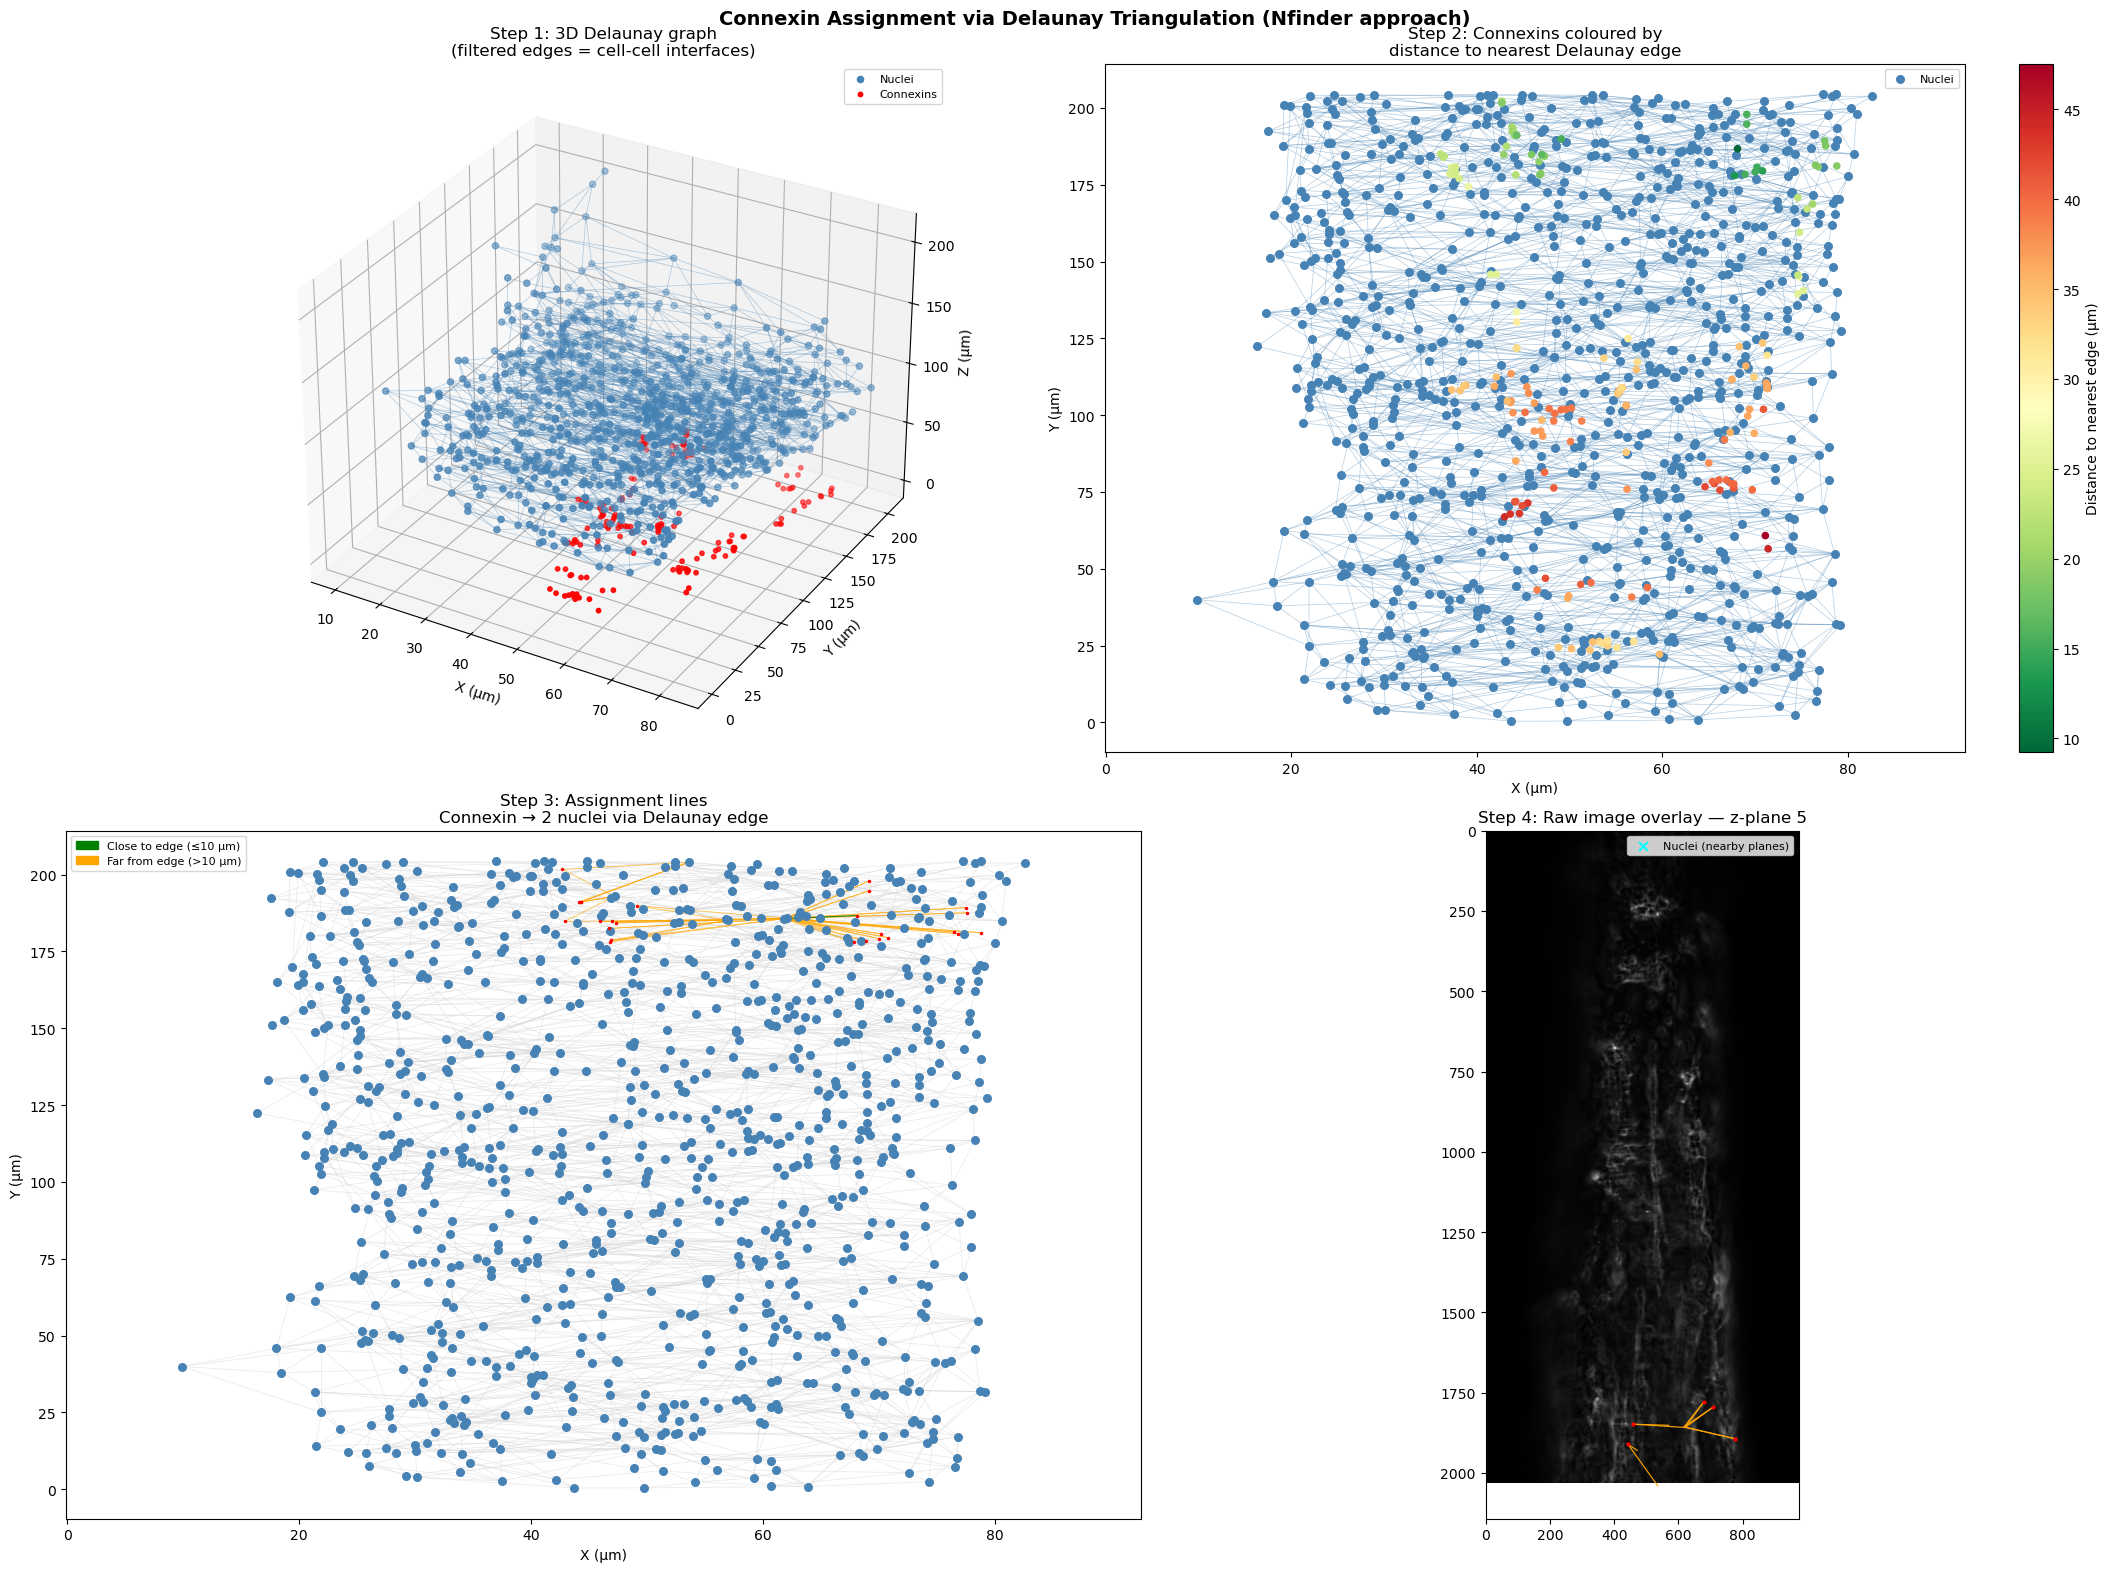

In [14]:
# Step 3 — visualize
visualize_delaunay_assignment(
    result,
    nuclei_coords_um,
    edges,
    cnx,
    xy_pixel_size = 0.1,
    z_step_size   = 0.5,
    z_plane       = 5,
    save_path     = 'delaunay_assignment.png'
)

In [15]:
#save 
result.to_csv('connexin_delaunay_assignments.csv', index=False)